Dataset exploration

The goal of this notebook is to understand the structure of the provided data and verify some statements from Kaggle
Description on Kaggle claims the following
- images are 224 x 224 x 3
- there are 100 different sports
- 13493 train images, 500 test images, 500 validation images

In [17]:
import torch
import numpy
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

In [29]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [37]:
dataset = datasets.ImageFolder(
    root="../data/raw/train",  # just importing test data for now since it is smaller
    transform=transform
)
dataset_test = datasets.ImageFolder(
    root="../data/raw/test",  # just importing test data for now since it is smaller
    transform=transform
)
dataset_validation = datasets.ImageFolder(
    root="../data/raw/valid")

In [39]:
# print(dataset.classes)
# print(dataset.class_to_idx)
print("Number of images in train dataset", len(dataset))
print("Number of sports in train dataset", len(dataset.classes))

print("Number of images in test dataset", len(dataset_test))
print("Number of sports in test dataset", len(dataset_test.classes))

print("Number of images in validation dataset", len(dataset_validation))
print("Number of sports in validation dataset", len(dataset_validation.classes))

Number of images in train dataset 13492
Number of sports in train dataset 100
Number of images in test dataset 500
Number of sports in test dataset 100
Number of images in validation dataset 500
Number of sports in validation dataset 100


This shows the expected number of images per dataset and that all sports exist in each.

In [32]:
def show_image(img, label):
    img = img.permute(1, 2, 0)  # CHW → HWC
    plt.imshow(img)
    plt.title(dataset.classes[label])
    plt.axis("off")
    plt.show()

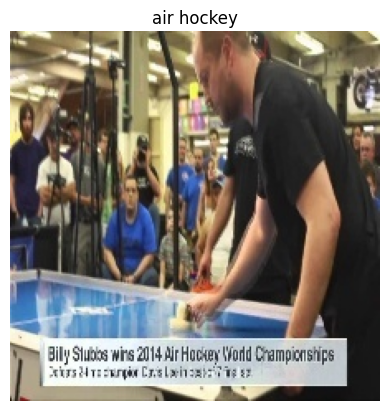

In [33]:
img, label = dataset[4]
show_image(img, label)

Demonstrates successful loading (and display) of an image. Also verifies the image channel permutation.

In [34]:
loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2
)

In [35]:
images, labels = next(iter(loader))
print(images.shape)  # [B, 3, 224, 224]
print(labels)

torch.Size([8, 3, 224, 224])
tensor([76, 70, 86, 66, 75, 97, 16, 68])
